# Walkthrough

A walkthrough of the entire experiment for an eligible complex. Expects data under `/src/data/`:

- `/src/data/diffdock`: contains candidate poses per complex.
- `/src/data/posebusters`: contains protein files.

In [1]:
import os
import pandas as pd

import utils, prepare, encode, filter, motivation, confidence, sapt, run

In [2]:
OUT = run.OUT
NAME = "v1_1_mm_unsize"
JOB = os.path.join(OUT, f"filter_{NAME}")
FILTERED = os.path.join(JOB, "filter.csv")
CHOSEN = os.path.join(JOB, "chosen.csv")
SAPT_SUMMARY = os.path.join(JOB, "sapt_summary.csv")

SCORED = [
    # The first batch, less 7OEO_V9Z, which timed out part way through its poses.
    "5SAK_ZRY", "7F5D_EUO", "7LOE_Y84", "7NGW_UAW", "7OSO_0V1", "7PRM_81I", "7Q2B_M6H", "7W05_GMP",
    "7XFA_D9J", "7Z2O_IAJ", "8DSC_NCA",
    # The second batch, less 7XI7_4RI, 7WJB_BGC, 7N4W_P4V and 7RKW_5TV, which are kept for the
    #     compute-cost table alone.
    "7BJJ_TVW", "7R59_I5F", "6YQW_82I",
]


# Experiment Filter and Preparation

Before the protein (monomer A) and poses (monomer Bs) are encoded, the complex must be prepared. Preparation loads the proteins and poses, verifies they are in scope, cleans them, fixes them, protonates both sides, minimises the poses, reverifies, then finally calculates the net charge and verifies that the number of electrons is even.

`filter` prepares all complexes DiffDock ran over and returns the generated artefacts for eligible ones.

In [9]:
# WARNING: takes several hours
# filter.run(name="_v1_1_mm_unsize")

In [10]:
filtered = pd.read_csv(FILTERED)
filtered.head()

,name,status,heavy_atoms,charge,electrons,ligand_heavy_atoms,ligand_electrons,poses,excluded,near_native,rejection
0,5SAK_ZRY,eligible,300,-6,2282,18,124,36,4,7,NaN
1,5SB2_1K2,eligible,297,-1,2306,30,218,40,0,40,NaN
2,6XG5_TOP,eligible,270,-3,2064,21,154,37,2,32,NaN
3,6YQW_82I,eligible,103,0,772,11,90,40,0,38,NaN
4,6ZCY_QF8,eligible,233,-1,1808,33,236,40,0,20,NaN


In [ ]:
chosen = filtered.copy()
chosen["difficulty"] = chosen["near_native"] / chosen["poses"]
chosen = chosen[
    (chosen["status"] == "eligible") 
        & (chosen["difficulty"] < 1)
]
chosen = chosen.sort_values(by=["electrons"])[:30]
chosen

,name,status,heavy_atoms,charge,electrons,ligand_heavy_atoms,ligand_electrons,poses,excluded,near_native,rejection,difficulty
5,7BJJ_TVW,eligible,96,-1,756,10,70,40,0,26,NaN,0.650000
3,6YQW_82I,eligible,103,0,772,11,90,40,0,38,NaN,0.950000
27,7R59_I5F,eligible,130,0,982,13,98,40,0,32,NaN,0.800000
11,7LOE_Y84,eligible,147,0,1144,11,76,40,0,1,NaN,0.025000
9,7F5D_EUO,eligible,163,-3,1226,21,158,40,0,8,NaN,0.200000
36,7W05_GMP,eligible,183,-1,1364,20,148,39,1,5,NaN,0.128205
39,7XI7_4RI,eligible,192,-2,1470,20,146,40,0,39,NaN,0.975000
18,7OEO_V9Z,eligible,210,-1,1594,32,230,40,0,7,NaN,0.175000
12,7MMH_ZJY,eligible,215,2,1638,57,432,30,10,16,NaN,0.533333
10,7JXX_VP7,eligible,217,-1,1696,25,176,40,0,39,NaN,0.975000


In [12]:
filtered.to_csv(CHOSEN)

# Encoding

`EncodeProtein` solves the RHF for the cutout (runtime: hours), determines its active space with AVAS, takes the 50 orbitals with the most fractional occupancy (strong correlation), as calculated with MP2, then reduces the space further with SHCI to a maximum of 14 orbitals. Finally, the compressed active space can be encoded as a Hamiltonian for VQE, or classically solved with CASCI.

`SolveLigand` does not treat the ligand as a quantum-mechanical system; it only solves its RHF.

Note that takes several hours and requires Dice set up.

In [ ]:
out = os.path.join(OUT, NAME)
for complex in run._load(out, SCORED):
    complex.prepare()
    ligand = encode.SolveLigand(complex, complex.out)
    ligand.RHF()
    protein = encode.EncodeProtein(complex, complex.out)
    protein.solve()
    protein.rewindow()
    protein.encode()
    protein.CASCI()

# SAPT

We can determine the interaction energy of a solved complex and rank its poses with the `sapt` library.

Determining the energy can take hours; ranking them is quick.

In [ ]:
for complex in run._load(out, SCORED):
    scorer = sapt.SAPT(protein, ligand, complex.out)


In [ ]:
rows, summary = sapt.run(NAME)

Complexes 7
  not scored 5 ['5SAK_ZRY', '7NGW_UAW', '7OEO_V9Z', '7PRM_81I', '7XFA_D9J']

Over 7 complexes

                                                   top-1        D
  ranked on E_int                              5   71.4%    0.766
  re-scored by DiffDock's confidence model     3   42.9%    0.648
  as DiffDock ranked them                      0    0.0%    0.574
  a random pick off the ensemble                   14.9%    0.500


# Results

This section provides all figures and tables found in the thesis write-up.

**Motivation**

This preliminary result demonstrates that DiffDock's confidence model does not appear to carry any pose-ranking information. Taking the poses provdied by PoseBench datasets, we evaluate the top-1 success against the percentage of near-native poses in a complex.

In [ ]:
rows, figure = motivation.run()

Complexes 280
Poses 11008, 2982 near-native (27.1%)

Top-1 and pairwise discrimination by how much of the ensemble is near-native

      band     n    top-1   chance        D
        0%   137     0.0%     0.0%         
       25%    46    26.1%    12.6%    0.673
       50%    29    37.9%    39.5%    0.556
       75%    19    78.9%    60.1%    0.713
      100%    49    93.9%    95.8%    0.790
       all   280    30.0%    27.0%    0.674

Wrote out/motivation.png


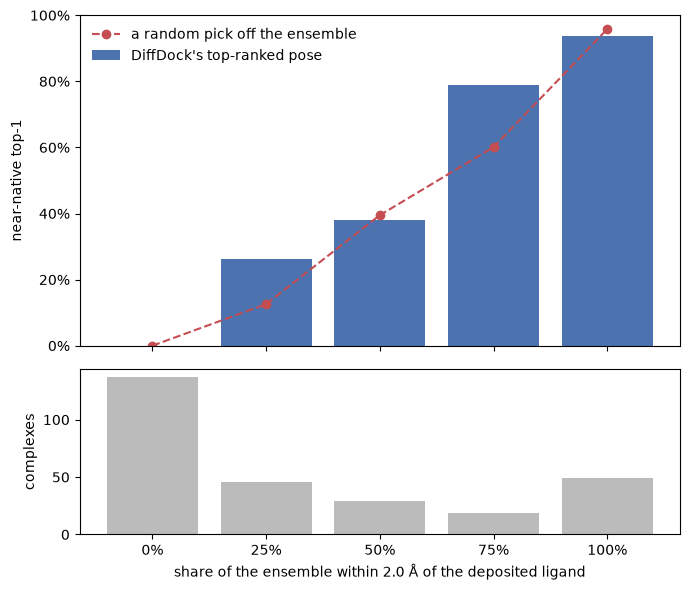

In [ ]:
%matplotlib inline
figure

**Preparation**

The summary provided by `filter` describes how scoping decisions and validity affect the cohort.

In [ ]:
filter.run(name=NAME, strict=True)

Screening: 100%|██████████| 143/143 [53:55<00:00, 22.63s/complex]  

Screened 280
Eligible 47
Rejected 89
    60  ligand carrying a group ionised at pH 7.4
    25  cutout exceeds the heavy-atom cap
     4  ligand with a non-zero formal charge
Failed 0
Generator 137 (no near-native pose generated)
Unusable 7 (no near-native pose after preparation)

Poses 1870 over 47 eligible complexes
   173  excluded by PoseBusters
  1697  kept, 1128 of them near-native

Checks failed, by pose

    404  minimum_distance_to_protein
    302  bond_angles
    280  bond_lengths
    171  volume_overlap_with_protein
    131  aromatic_ring_flatness
     61  internal_energy
     53  internal_steric_clash

Size quartiles of the 47 eligible cutouts, by heavy atoms in the capped cutout

  bin     heavy atoms     n   q=0  q!=0
  Q1         96 - 208    12     3     9
  Q2        210 - 254    12     2    10
  Q3        261 - 308    11     3     8
  Q4        310 - 382    12     5     7
  all        96 - 382    47    13    34

Charge magnitude

  bin     |q|=0   |q|=1-2   |q|>=3
  Q1 

**Results**

Below we show the aggregate and per-complex statistics for the proposesd interaction energy score, the re-evaluated DiffDock confidence, the original, pre-minimisation confidence, and what we would expect from a random ranker.

In [ ]:
# Prepare for sapt.run over the 14 complexes
import shutil

BACKUP = os.path.join(JOB, "confidence_all.csv")
if not os.path.exists(BACKUP):
    shutil.copyfile(os.path.join(JOB, confidence.TABLE_NAME), BACKUP)

confidence.run(complexes=SCORED, reuse=True, name=NAME, plot=False)

Complexes 14

Over 14 complexes

                                                   top-1        D
  re-scored by DiffDock's confidence model     6   42.9%    0.677
  as DiffDock ranked them                      4   28.6%    0.658
  a random pick off the ensemble                   32.4%    0.500


([{'name': '5SAK_ZRY',
   'source': 'rank15_confidence-0.56.sdf',
   'rank_docked': 15,
   'confidence_docked': -0.56,
   'rank_minimised': 1,
   'confidence_minimised': -0.10218106955289841,
   'rmsd': 6.095162315403184},
  {'name': '5SAK_ZRY',
   'source': 'rank4_confidence-0.28.sdf',
   'rank_docked': 4,
   'confidence_docked': -0.28,
   'rank_minimised': 2,
   'confidence_minimised': -0.1706652045249939,
   'rmsd': 4.884946745928307},
  {'name': '5SAK_ZRY',
   'source': 'rank20_confidence-0.68.sdf',
   'rank_docked': 20,
   'confidence_docked': -0.68,
   'rank_minimised': 3,
   'confidence_minimised': -0.2363647222518921,
   'rmsd': 5.964822900602795},
  {'name': '5SAK_ZRY',
   'source': 'rank28_confidence-0.74.sdf',
   'rank_docked': 28,
   'confidence_docked': -0.74,
   'rank_minimised': 4,
   'confidence_minimised': -0.24718543887138367,
   'rmsd': 6.429237241003875},
  {'name': '5SAK_ZRY',
   'source': 'rank1_confidence-0.26.sdf',
   'rank_docked': 1,
   'confidence_docked': -0

In [3]:
rows, summary = sapt.run(NAME)

Complexes 14

Over 14 complexes

                                                   top-1        D
  ranked on E_int                              8   57.1%    0.730
  ranked on E_int, no cumulant                 8   57.1%    0.731
  re-scored by DiffDock's confidence model     6   42.9%    0.677
  as DiffDock ranked them                      4   28.6%    0.658
  a random pick off the ensemble                   32.4%    0.500

The 14 of 14 complexes scored at SAPT(RHF) too

Over 14 complexes

                                                   top-1        D
  ranked on E_int, SAPT(RHF)                   7   50.0%    0.729
  ranked on E_int                              8   57.1%    0.730
  ranked on E_int, no cumulant                 8   57.1%    0.731
  re-scored by DiffDock's confidence model     6   42.9%    0.677
  as DiffDock ranked them                      4   28.6%    0.658
  a random pick off the ensemble                   32.4%    0.500

The cumulant moves 14 of 510 poses. Spea

In [4]:
# Aggregate
sapt_summary = pd.read_csv(SAPT_SUMMARY)
METHODS = {
    "docked": "DD(PreMM)",
    "minimised": "DD(PostMM)",
    "rhf": "SAPT(RHF)",
    "sapt": "SAPT(CASCI)",
    "separable": "SAPT(CASCI)-"
}
METRICS = {"top1": "Top-1", "discrimination": "Pairwise Discrimination"}
RANDOM = {"top1": sapt_summary["fraction"].mean(), "discrimination": 0.5}
aggregate = pd.DataFrame(
    {label: [sapt_summary[f"{metric}_{method}"].mean() for metric in METRICS] for method, label in METHODS.items()}
    | {"Random": [RANDOM[metric] for metric in METRICS]},
    index=list(METRICS.values()),
)
aggregate

,DD(PreMM),DD(PostMM),SAPT(RHF),SAPT(CASCI),SAPT(CASCI)-,Random
Top-1,0.285714,0.428571,0.500000,0.571429,0.571429,0.323759
Pairwise Discrimination,0.658150,0.676503,0.728567,0.729952,0.731004,0.500000


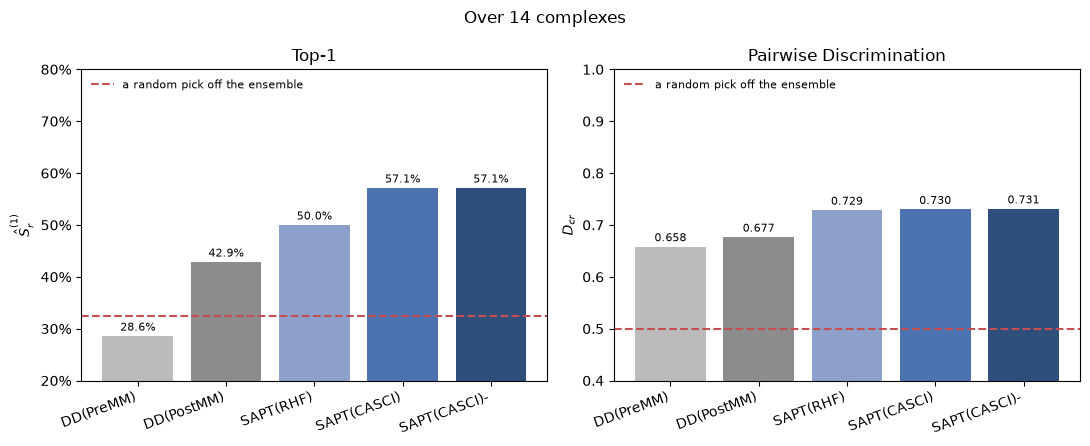

In [5]:
# Top-1 ($\hat S^{(1)}_r)$) and Pairwise Discrimination ($D_{cr}$) bar graphs across the methods above.
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Read off METHODS so the bars and the per-complex table below cannot fall out of step.
ORDER = list(METHODS.values())
COLOURS = ["#BBBBBB", "#8C8C8C", "#8DA0CB", "#4C72B0", "#2E4F7C"]
SYMBOLS = {"top1": "$\\hat{S}^{(1)}_r$", "discrimination": "$D_{cr}$"}
FORMATS = {"top1": "{:.1%}", "discrimination": "{:.3f}"}
LIMITS = {"top1": (0.2, 0.8), "discrimination": (0.4, 1.0)}
CHANCE = "#C44E52"

bars = aggregate[ORDER]
positions = range(len(ORDER))

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for axis, (metric, label) in zip(axes, METRICS.items()):
    drawn = axis.bar(positions, bars.loc[label], color=COLOURS)
    axis.axhline(
        RANDOM[metric], linestyle="--", color=CHANCE, label="a random pick off the ensemble"
    )
    axis.bar_label(
        drawn, labels=[FORMATS[metric].format(one) for one in bars.loc[label]], padding=2, fontsize=8
    )
    axis.set_xticks(list(positions), ORDER, rotation=20, ha="right")
    axis.set_ylim(*LIMITS[metric])
    axis.set_title(label)
    axis.set_ylabel(SYMBOLS[metric])
    axis.legend(frameon=False, loc="upper left", fontsize=8)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
figure.suptitle(f"Over {len(sapt_summary)} complexes")
figure.tight_layout()
figure.savefig(os.path.join(JOB, "aggregate.png"), dpi=200)

In [6]:
# Per-complex
complex_info = pd.read_csv(FILTERED)
DROPPED = ["poses", "near_native", "status", "rejection", "excluded"]
INFO = {
    "poses": "Poses",
    "near_native": "Near Native",
    "fraction": "Fraction",
    "heavy_atoms": "Heavy Atoms",
    "charge": "Charge",
    "electrons": "Electrons",
    "ligand_heavy_atoms": "Ligand Heavy Atoms",
    "ligand_electrons": "Ligand Electrons"
}
DIAGNOSTIC = {
    "moved": "Cumulant Moved",
    "moved_rhf": "Correlation Moved",
    "retention": "Retention",
    "spearman_separable": "Cumulant Spearman",
    "spearman_rhf": "Correlation Spearman"
}

merged = sapt_summary.merge(complex_info.drop(columns=DROPPED), on="name").set_index("name")
merged.index.name = "Name"
merged = merged.astype({"heavy_atoms": int, "charge": int, "electrons": int, "moved": int})

tiers = {"Complex Information": merged[list(INFO)].rename(columns=INFO)}
for method, label in METHODS.items():
    tiers[label] = merged[[f"{metric}_{method}" for metric in METRICS]].set_axis(list(METRICS.values()), axis=1)
tiers["Diagnostic"] = merged[list(DIAGNOSTIC)].rename(columns=DIAGNOSTIC)
per_complex = pd.concat(tiers, axis=1)
per_complex.to_csv(os.path.join(JOB, "per_complex.csv"))
per_complex

Complex Information                                           \
                       Poses Near Native  Fraction Heavy Atoms Charge   
Name                                                                    
5SAK_ZRY                  36           7  0.194444         300     -6   
6YQW_82I                  40          38  0.950000         103      0   
7BJJ_TVW                  40          26  0.650000          96     -1   
7F5D_EUO                  40           8  0.200000         163     -3   
7LOE_Y84                  40           1  0.025000         147      0   
7NGW_UAW                  39          16  0.410256         292     -1   
7OSO_0V1                  37           8  0.216216         228     -1   
7PRM_81I                  15           5  0.333333         298      0   
7Q2B_M6H                  37           1  0.027027         268     -3   
7R59_I5F                  40          32  0.800000         130      0   
7W05_GMP                  39           5  0.128205         183     -1   
7XFA_D9J                  27           4  0.148148         231      1   
7Z2O_IAJ                  40           3  0.075000         251      0   
8DSC_NCA                  40          15  0.375000         274      1   

                                                       DD(PreMM)  \
         Electrons Ligand Heavy Atoms Ligand Electrons     Top-1   
Name                                                               
5SAK_ZRY      2282                 18              124     False   
6YQW_82I       772                 11               90     False   
7BJJ_TVW       756                 10               70      True   
7F5D_EUO      1226                 21              158     False   
7LOE_Y84      1144                 11               76     False   
7NGW_UAW      2218                 17              126      True   
7OSO_0V1      1720                  7               58     False   
7PRM_81I      2314                 32              228     False   
7Q2B_M6H      2038                 12               88     False   
7R59_I5F       982                 13               98      True   
7W05_GMP      1364                 20              148     False   
7XFA_D9J      1760                 41              316      True   
7Z2O_IAJ      1870                 14              106     False   
8DSC_NCA      2088                  9               64     False   

                                  ...               SAPT(RHF) SAPT(CASCI)  \
         Pairwise Discrimination  ... Pairwise Discrimination       Top-1   
Name                              ...                                       
5SAK_ZRY                0.938424  ...                0.862069       False   
6YQW_82I                0.000000  ...                1.000000        True   
7BJJ_TVW                0.978022  ...                0.771978        True   
7F5D_EUO                0.904297  ...                0.894531        True   
7LOE_Y84                0.743590  ...                1.000000        True   
7NGW_UAW                0.887228  ...                0.301630       False   
7OSO_0V1                0.232759  ...                0.413793       False   
7PRM_81I                0.560000  ...                0.380000       False   
7Q2B_M6H                0.972222  ...                0.333333       False   
7R59_I5F                0.878906  ...                1.000000        True   
7W05_GMP                0.861765  ...                0.723529        True   
7XFA_D9J                0.956522  ...                0.521739       False   
7Z2O_IAJ                0.027027  ...                1.000000        True   
8DSC_NCA                0.273333  ...                0.997333        True   

                                 SAPT(CASCI)-                          \
         Pairwise Discrimination        Top-1 Pairwise Discrimination   
Name                                                                    
5SAK_ZRY                0.862069        False                0.862069   
6YQW_82I

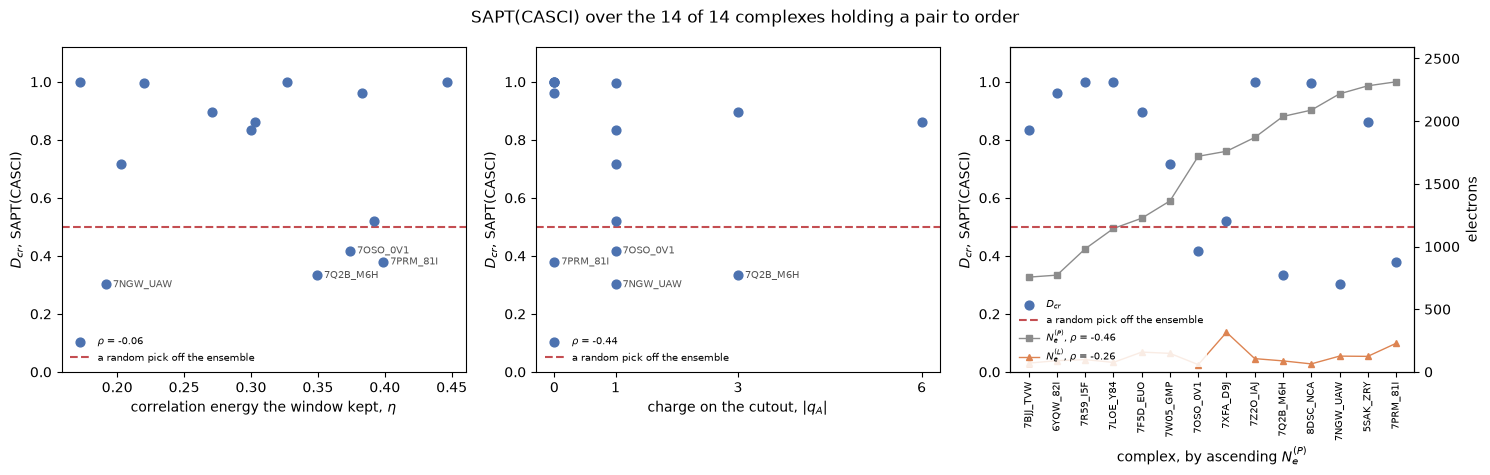

In [7]:
# Graphs displaying SAPT(CASCI) from per_complex
# Pairwise Discrimination ($D_{cr}$) against retention ($\eta$); 
# $D_{cr}$ against charge ($q_A$);
# $D_{cr}$ against protein num electrons $N_e^{(P)}$ (ascending) and electron num electrons $N_e^{(L)}$ (matched to complex)
from utils import report

INFORMATION, DIAGNOSTICS = "Complex Information", "Diagnostic"
CASCI, DISCRIMINATION = METHODS["sapt"], METRICS["discrimination"]
PROTEIN, LIGAND = (INFORMATION, "Electrons"), (INFORMATION, "Ligand Electrons")
LEGEND = dict(frameon=True, framealpha=0.85, edgecolor="none", fontsize=7, loc="lower left")

# A complex whose ensemble holds no pair to order carries no D, so it cannot be placed. The rest
#     are laid out by the size of their cutout, which the third panel reads along its x axis.
ordered = per_complex.dropna(subset=[(CASCI, DISCRIMINATION)]).sort_values(by=[PROTEIN])
discriminated = ordered[(CASCI, DISCRIMINATION)]
positions = range(len(ordered))

# Charge tells on the cutout by how far from neutral it is, either way, so it is taken absolute.
charges = ordered[(INFORMATION, "Charge")].abs()
AGAINST = [
    (ordered[(DIAGNOSTICS, "Retention")], "correlation energy the window kept, $\\eta$"),
    (charges, "charge on the cutout, $|q_A|$"),
]


def rho(values):
    return f"$\\rho$ = {report.spearman_correlate(values, discriminated):+.2f}"


figure, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for axis, (values, label) in zip(axes, AGAINST):
    axis.scatter(values, discriminated, s=40, color="#4C72B0", zorder=3, label=rho(values))
    # The complexes the score ranks no better than chance are the ones worth naming.
    for name, position, height in zip(ordered.index, values, discriminated):
        if height < 0.5:
            axis.annotate(
                name, (position, height), textcoords="offset points", xytext=(5, -2), fontsize=7,
                color="#555555",
            )
    axis.set_xlabel(label)
axes[1].set_xticks(sorted(set(charges)))

# Both sides' sizes read off the same complexes, which the panel orders by the cutout's. The ticks
#     name every complex, so its points need no labels of their own.
axes[2].scatter(positions, discriminated, s=40, color="#4C72B0", zorder=3, label="$D_{cr}$")
axes[2].set_xticks(list(positions), list(ordered.index), rotation=90, fontsize=7)
axes[2].set_xlabel("complex, by ascending $N_e^{(P)}$")
electrons = axes[2].twinx()
for column, colour, mark, name in (
    (PROTEIN, "#8C8C8C", "s", "$N_e^{(P)}$"), (LIGAND, "#DD8452", "^", "$N_e^{(L)}$")
):
    electrons.plot(
        positions, ordered[column], mark + "-", color=colour, markersize=4, linewidth=1,
        label=f"{name}, {rho(ordered[column])}",
    )
electrons.set_ylabel("electrons")
electrons.set_ylim(0, ordered[PROTEIN].max() * 1.12)
axes[2].set_zorder(electrons.get_zorder() + 1)
axes[2].patch.set_visible(False)

for axis in axes:
    axis.axhline(0.5, linestyle="--", color=CHANCE, label="a random pick off the ensemble")
    axis.set_ylabel(f"$D_{{cr}}$, {CASCI}")
    axis.set_ylim(0, 1.12)
    axis.legend(**LEGEND)
handles, labels = axes[2].get_legend_handles_labels()
extra = electrons.get_legend_handles_labels()
axes[2].legend(handles + extra[0], labels + extra[1], **LEGEND)

figure.suptitle(f"{CASCI} over the {len(ordered)} of {len(per_complex)} complexes holding a pair "
                "to order")
figure.tight_layout()
figure.savefig(os.path.join(JOB, "per_complex.png"), dpi=200)

**Compute time**

We report the compute times for steps (where recorded) across the 19 complexes attempted.

In [8]:
# Join `compute_time.csv` with complex number of electrons (protein and ligand) in a PD dataframe.
# Sort by Protein Solve first (where the empty cells come FIRST), then Per-Pose Score second.
# Simply print the dataframe below.
COMPUTE_TIME = os.path.join(run.ROOT, "compute_time.csv")
ELECTRONS = {"electrons": "Electrons", "ligand_electrons": "Ligand Electrons"}
SOLVE, PER_POSE = "Protein Solve (RHF, AVAS, MP2, SHCI) (s)", "Per-Pose Score (s)"

# Merged onto the times rather than the other way round, so the two sizes read before them. The
#     complexes with no pipeline timing come first, ordered by what a pose cost them instead.
compute_time = (
    complex_info[["name", *ELECTRONS]]
    .rename(columns={"name": "Complex", **ELECTRONS})
    .merge(pd.read_csv(COMPUTE_TIME), on="Complex", how="right")
    .sort_values(by=[SOLVE, PER_POSE], na_position="first")
    .set_index("Complex")
)
compute_time

,Electrons,Ligand Electrons,Poses,Poses Scored,"Protein Solve (RHF, AVAS, MP2, SHCI) (s)",CASCI (Encoding and solve) (s),Ligand Solve (s),Per-Pose Score (s),"Per-Pose Score, SAPT(RHF) (s)"
Complex,,,,,,,,,
8DSC_NCA,2088,64,40,40.0,NaN,NaN,NaN,1125.0,487.0
7LOE_Y84,1144,76,40,40.0,NaN,NaN,NaN,1180.0,472.0
7OSO_0V1,1720,58,37,37.0,NaN,NaN,NaN,1185.0,572.0
7W05_GMP,1364,148,39,39.0,NaN,NaN,NaN,1625.0,515.0
7Z2O_IAJ,1870,106,40,40.0,NaN,NaN,NaN,1728.0,646.0
7F5D_EUO,1226,158,40,40.0,NaN,NaN,NaN,1763.0,772.0
7XFA_D9J,1760,316,27,27.0,NaN,NaN,NaN,1927.0,1954.0
7Q2B_M6H,2038,88,37,37.0,NaN,NaN,NaN,2753.0,872.0
7PRM_81I,2314,228,15,15.0,NaN,NaN,NaN,3527.0,3423.0
